<a href="https://colab.research.google.com/github/RiteshD11/Satellite-Assisted-District-Level-Sugarcane-Yield-Forecasting/blob/Ritesh/01_GEE_Data_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install earthengine-api geemap geopandas

In [7]:
import ee
import geemap
import pandas as pd
import geopandas as gpd

In [12]:
ee.Authenticate()

In [13]:
try:
    ee.Initialize(project="sugarcane-yield-forecasting")
    print("✅ Earth Engine initialized successfully!")
except Exception as e:
    print(e)

✅ Earth Engine initialized successfully!


In [14]:
india = ee.FeatureCollection("FAO/GAUL/2015/level2")

maharashtra = india.filter(
    ee.Filter.eq("ADM1_NAME", "Maharashtra")
)

print(maharashtra.size().getInfo())

35


In [15]:
Map = geemap.Map()

Map.centerObject(maharashtra, 7)

Map.addLayer(maharashtra, {}, "Maharashtra Districts")

Map

Map(center=[19.45063009771838, 76.09460849203751], controls=(WidgetControl(options=['position', 'transparent_b…

In [16]:
import ee

ee.Authenticate()
ee.Initialize(project="sugarcane-yield-forecasting")

districts = ee.FeatureCollection(
    "projects/sugarcane-yield-forecasting/assets/india_districts"
)

print("Number of districts:", districts.size().getInfo())

print(districts.first().getInfo())

Number of districts: 676
{'type': 'Feature', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[93.61147356900412, 8.484469846842666], [93.61187490605631, 8.484541135913105], [93.6125036197814, 8.484750771503522], [93.61305211806766, 8.485000435967923], [93.61360943308078, 8.485276937145613], [93.61369421722642, 8.485571169440641], [93.61348909703209, 8.48605282561518], [93.61308326447936, 8.486338207266057], [93.61257943692793, 8.486409478095315], [93.61194623974417, 8.4863292900693], [93.61154041964826, 8.486052808365658], [93.61111682764815, 8.485834256681631], [93.61111682764815, 8.485557799820928], [93.61083142092991, 8.485276866779701], [93.61083142092991, 8.485000411895854], [93.61147356900412, 8.484469846842666]]], [[[93.63055403120346, 7.477778672892201], [93.63083498835222, 7.477783131861812], [93.63223515866876, 7.476391953272406], [93.63268104106945, 7.475798853863758], [93.63314927209669, 7.475522428978521], [93.63385827617874, 7.4755803379602295], [93.63440669807123,

In [17]:
first = districts.first()

print(first.propertyNames().getInfo())

['ENGTYPE_2', 'NL_NAME_2', 'NL_NAME_1', 'HASC_2', 'NAME_2', 'CC_2', 'NAME_1', 'TYPE_2', 'COUNTRY', 'GID_0', 'GID_1', 'system:index', 'GID_2', 'VARNAME_2']


In [18]:
print(first.toDictionary().getInfo())

{'CC_2': 'NA', 'COUNTRY': 'India', 'ENGTYPE_2': 'District', 'GID_0': 'IND', 'GID_1': 'IND.1_1', 'GID_2': 'IND.1.1_1', 'HASC_2': 'IN.AN.NI', 'NAME_1': 'Andaman and Nicobar', 'NAME_2': 'Nicobar Islands', 'NL_NAME_1': 'NA', 'NL_NAME_2': 'NA', 'TYPE_2': 'District', 'VARNAME_2': 'NA'}


In [19]:
# Filter only Maharashtra districts

maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

print("Number of Maharashtra Districts:",
      maharashtra.size().getInfo())

# Print district names

district_names = maharashtra.aggregate_array("NAME_2").getInfo()

print(district_names)

Number of Maharashtra Districts: 36
['Ahmadnagar', 'Amravati', 'Bid', 'Chandrapur', 'Dhule', 'Jalgaon', 'Latur', 'Nanded', 'Nashik', 'Pune', 'Raigarh', 'Sangli', 'Satara', 'Sindhudurg', 'Solapur', 'Thane', 'Yavatmal', 'Akola', 'Aurangabad', 'Bhandara', 'Buldana', 'Garhchiroli', 'Gondiya', 'Hingoli', 'Jalna', 'Kolhapur', 'Mumbai City', 'Mumbai Suburban', 'Nagpur', 'Nandurbar', 'Osmanabad', 'Palghar', 'Parbhani', 'Ratnagiri', 'Wardha', 'Washim']


In [20]:
import ee
import pandas as pd

ee.Initialize(project="sugarcane-yield-forecasting")

# Load district boundaries
districts = ee.FeatureCollection(
    "projects/sugarcane-yield-forecasting/assets/india_districts"
)

# Filter Maharashtra
maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

# Select one district for testing
district = maharashtra.filter(
    ee.Filter.eq("NAME_2", "Ahmednagar")
).first()

start = ee.Date("2010-01-01")
end = start.advance(1, "month")

# ---------------- MODIS ----------------
modis = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(start, end)
    .select(["NDVI", "EVI"])
    .mean()
)

# Scale factor
ndvi = (
    modis.select("NDVI")
    .multiply(0.0001)
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=district.geometry(),
        scale=250,
        maxPixels=1e13
    )
)

evi = (
    modis.select("EVI")
    .multiply(0.0001)
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=district.geometry(),
        scale=250,
        maxPixels=1e13
    )
)

# ---------------- CHIRPS ----------------
rain = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(start, end)
    .sum()
)

rainfall = rain.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=district.geometry(),
    scale=5000,
    maxPixels=1e13
)

# ---------------- ERA5 ----------------
temp = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterDate(start, end)
    .first()
)

temperature = temp.select("temperature_2m").subtract(273.15).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=district.geometry(),
    scale=10000,
    maxPixels=1e13
)

print("District:", "Ahmednagar")
print("NDVI:", ndvi.getInfo())
print("EVI:", evi.getInfo())
print("Rainfall:", rainfall.getInfo())
print("Temperature:", temperature.getInfo())

District: Ahmednagar


EEException: Element.geometry: Parameter 'feature' is required and may not be null.

In [22]:
# Filter Maharashtra
maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

print("Total districts:", maharashtra.size().getInfo())

# Print all district names
district_names = sorted(maharashtra.aggregate_array("NAME_2").getInfo())

for name in district_names:
    print(name)

Total districts: 36
Ahmadnagar
Akola
Amravati
Aurangabad
Bhandara
Bid
Buldana
Chandrapur
Dhule
Garhchiroli
Gondiya
Hingoli
Jalgaon
Jalna
Kolhapur
Latur
Mumbai City
Mumbai Suburban
Nagpur
Nanded
Nandurbar
Nashik
Osmanabad
Palghar
Parbhani
Pune
Raigarh
Ratnagiri
Sangli
Satara
Sindhudurg
Solapur
Thane
Wardha
Washim
Yavatmal


In [23]:
# Select Ahmadnagar district
district = maharashtra.filter(
    ee.Filter.eq("NAME_2", "Ahmadnagar")
).first()

print(district.getInfo())


{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[73.63020162659373, 19.583069757324658], [73.63722020268447, 19.572608680510033], [73.63833499603973, 19.56314201178783], [73.63610100155852, 19.546438271465252], [73.63479000405695, 19.542768428775585], [73.64367702691221, 19.538982656791756], [73.64364576688297, 19.53284244292503], [73.64570586448015, 19.530782311451755], [73.64817626554333, 19.536449839719285], [73.66493804124735, 19.534831238471007], [73.67162221198578, 19.529092391033412], [73.67382052159616, 19.526100290328554], [73.67703998388818, 19.517547775352394], [73.67679479424605, 19.514341673179825], [73.68743862689206, 19.51225924784015], [73.69077399416332, 19.517587866447915], [73.69487642350397, 19.51620999548913], [73.69713716512234, 19.508923847341713], [73.707963840922, 19.50528968486063], [73.71160696687166, 19.500179503737236], [73.71749743138565, 19.49638927758089], [73.71559780720304, 19.483083353619495], [73.70535084322317, 19.48188828134308

In [24]:
import ee

ee.Initialize(project="sugarcane-yield-forecasting")

start = ee.Date("2010-01-01")
end = start.advance(1, "month")

modis = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(start, end)
    .select(["NDVI", "EVI"])
    .mean()
)

ndvi = modis.select("NDVI").multiply(0.0001).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=district.geometry(),
    scale=250,
    maxPixels=1e13
)

evi = modis.select("EVI").multiply(0.0001).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=district.geometry(),
    scale=250,
    maxPixels=1e13
)

print("NDVI:", ndvi.getInfo())
print("EVI:", evi.getInfo())

NDVI: {'NDVI': 0.4246157200113822}
EVI: {'EVI': 0.2376676141242387}


In [25]:
import ee
import pandas as pd
from tqdm import tqdm

ee.Initialize(project="sugarcane-yield-forecasting")

districts = ee.FeatureCollection(
    "projects/sugarcane-yield-forecasting/assets/india_districts"
)

maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

print("Districts:", maharashtra.size().getInfo())

Districts: 36


In [26]:
district_list = sorted(
    maharashtra.aggregate_array("NAME_2").getInfo()
)

district_list

['Ahmadnagar',
 'Akola',
 'Amravati',
 'Aurangabad',
 'Bhandara',
 'Bid',
 'Buldana',
 'Chandrapur',
 'Dhule',
 'Garhchiroli',
 'Gondiya',
 'Hingoli',
 'Jalgaon',
 'Jalna',
 'Kolhapur',
 'Latur',
 'Mumbai City',
 'Mumbai Suburban',
 'Nagpur',
 'Nanded',
 'Nandurbar',
 'Nashik',
 'Osmanabad',
 'Palghar',
 'Parbhani',
 'Pune',
 'Raigarh',
 'Ratnagiri',
 'Sangli',
 'Satara',
 'Sindhudurg',
 'Solapur',
 'Thane',
 'Wardha',
 'Washim',
 'Yavatmal']

In [27]:
results = []

for year in tqdm(range(2010, 2024)):

    for month in range(1,13):

        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1,'month')

        modis = (
            ee.ImageCollection("MODIS/061/MOD13Q1")
            .filterDate(start,end)
            .select(["NDVI","EVI"])
            .mean()
        )

        rainfall = (
            ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
            .filterDate(start,end)
            .sum()
        )

        temp = (
            ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
            .filterDate(start,end)
            .first()
        )

        for district_name in district_list:

            district = maharashtra.filter(
                ee.Filter.eq("NAME_2",district_name)
            ).first()

            geometry = district.geometry()

            ndvi = (
                modis.select("NDVI")
                .multiply(0.0001)
                .reduceRegion(
                    ee.Reducer.mean(),
                    geometry,
                    250,
                    maxPixels=1e13
                )
                .get("NDVI")
            )

            evi = (
                modis.select("EVI")
                .multiply(0.0001)
                .reduceRegion(
                    ee.Reducer.mean(),
                    geometry,
                    250,
                    maxPixels=1e13
                )
                .get("EVI")
            )

            rain = (
                rainfall.reduceRegion(
                    ee.Reducer.mean(),
                    geometry,
                    5000,
                    maxPixels=1e13
                )
                .get("precipitation")
            )

            temperature = (
                temp.select("temperature_2m")
                .subtract(273.15)
                .reduceRegion(
                    ee.Reducer.mean(),
                    geometry,
                    10000,
                    maxPixels=1e13
                )
                .get("temperature_2m")
            )

            results.append({
                "District":district_name,
                "Year":year,
                "Month":month,
                "NDVI":ndvi.getInfo() if ndvi else None,
                "EVI":evi.getInfo() if evi else None,
                "Rainfall":rain.getInfo() if rain else None,
                "Temperature":temperature.getInfo() if temperature else None
            })

  0%|          | 0/14 [05:36<?, ?it/s]


KeyboardInterrupt: 

In [28]:
satellite_df = pd.DataFrame(results)

satellite_df.to_csv(
    "Satellite_Dataset_Maharashtra_2010_2023.csv",
    index=False
)

satellite_df.head()

,District,Year,Month,NDVI,EVI,Rainfall,Temperature
0,Ahmadnagar,2010,1,0.424616,0.237668,0.000000,21.991703
1,Akola,2010,1,0.463822,0.233261,18.412046,20.796687
2,Amravati,2010,1,0.509642,0.254320,20.999653,19.886118
3,Aurangabad,2010,1,0.489103,0.271328,2.417351,21.191734
4,Bhandara,2010,1,0.540823,0.290944,11.039043,19.770002


In [29]:
from google.colab import files

files.download("Satellite_Dataset_Maharashtra_2010_2023.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import ee
import geemap

ee.Initialize(project="sugarcane-yield-forecasting")

In [31]:
districts = ee.FeatureCollection(
    "projects/sugarcane-yield-forecasting/assets/india_districts"
)

maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

print("Districts:", maharashtra.size().getInfo())

Districts: 36


In [32]:
def yearly_features(year):

    year = ee.Number(year)

    start = ee.Date.fromYMD(year,1,1)
    end = start.advance(1,'year')

    # MODIS
    modis = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .filterDate(start,end)
        .mean()
    )

    ndvi = modis.select("NDVI").multiply(0.0001)
    evi = modis.select("EVI").multiply(0.0001)

    # Rainfall
    rainfall = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
        .filterDate(start,end)
        .sum()
        .rename("Rainfall")
    )

    # Temperature
    temperature = (
        ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
        .filterDate(start,end)
        .select("temperature_2m")
        .mean()
        .subtract(273.15)
        .rename("Temperature")
    )

    image = ee.Image.cat([
        ndvi.rename("NDVI"),
        evi.rename("EVI"),
        rainfall,
        temperature
    ])

    table = image.reduceRegions(

        collection=maharashtra,

        reducer=ee.Reducer.mean(),

        scale=500

    )

    table = table.map(

        lambda f: f.set("Year",year)

    )

    return table

In [35]:
YEAR = 2010

In [37]:
import ee

ee.Initialize(project="sugarcane-yield-forecasting")

districts = ee.FeatureCollection(
    "projects/sugarcane-yield-forecasting/assets/india_districts"
)

maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

start = ee.Date.fromYMD(YEAR, 1, 1)
end = start.advance(1, 'year')

# MODIS
modis = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(start, end)
    .mean()
)

ndvi = modis.select("NDVI").multiply(0.0001).rename("NDVI")
evi = modis.select("EVI").multiply(0.0001).rename("EVI")

# CHIRPS Rainfall
rainfall = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(start, end)
    .sum()
    .rename("Rainfall")
)

# ERA5 Temperature
temperature = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterDate(start, end)
    .select("temperature_2m")
    .mean()
    .subtract(273.15)
    .rename("Temperature")
)

# Combine bands
image = ee.Image.cat([
    ndvi,
    evi,
    rainfall,
    temperature
])

# Extract district statistics
table = image.reduceRegions(
    collection=maharashtra,
    reducer=ee.Reducer.mean(),
    scale=1000
)

# Add Year property
table = table.map(lambda f: f.set("Year", YEAR))

# Export to Drive
task = ee.batch.Export.table.toDrive(
    collection=table,
    description=f"Satellite_{YEAR}",
    folder="EarthEngine",
    fileNamePrefix=f"Satellite_{YEAR}",
    fileFormat="CSV"
)

task.start()

print("Export Started:", YEAR)

Export Started: 2010


In [38]:
task.status()

{'state': 'COMPLETED',
 'description': 'Satellite_2010',
 'priority': 100,
 'creation_timestamp_ms': 1784397074755,
 'update_timestamp_ms': 1784397108739,
 'start_timestamp_ms': 1784397077977,
 'task_type': 'EXPORT_FEATURES',
 'destination_uris': ['https://drive.google.com/#folders/1s5uPbXSMLnLiQtwVig8G2hPCyJTmCXK_'],
 'attempt': 1,
 'batch_eecu_usage_seconds': 81.34166717529297,
 'id': '6ZLJOKB574ETRUPF4SYZ3ZDO',
 'name': 'projects/sugarcane-yield-forecasting/operations/6ZLJOKB574ETRUPF4SYZ3ZDO'}

In [71]:
YEAR = 2015

In [73]:
import ee

ee.Initialize(project="sugarcane-yield-forecasting")

districts = ee.FeatureCollection(
    "projects/sugarcane-yield-forecasting/assets/india_districts"
)

maharashtra = districts.filter(
    ee.Filter.eq("NAME_1", "Maharashtra")
)

start = ee.Date.fromYMD(YEAR, 1, 1)
end = start.advance(1, 'year')

# MODIS
modis = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(start, end)
    .mean()
)

ndvi = modis.select("NDVI").multiply(0.0001).rename("NDVI")
evi = modis.select("EVI").multiply(0.0001).rename("EVI")

# CHIRPS Rainfall
rainfall = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(start, end)
    .sum()
    .rename("Rainfall")
)

# ERA5 Temperature
temperature = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterDate(start, end)
    .select("temperature_2m")
    .mean()
    .subtract(273.15)
    .rename("Temperature")
)

# Combine bands
image = ee.Image.cat([
    ndvi,
    evi,
    rainfall,
    temperature
])

# Extract district statistics
table = image.reduceRegions(
    collection=maharashtra,
    reducer=ee.Reducer.mean(),
    scale=1000
)

# Add Year property
table = table.map(lambda f: f.set("Year", YEAR))

# Export to Drive
task = ee.batch.Export.table.toDrive(
    collection=table,
    description=f"Satellite_{YEAR}",
    folder="EarthEngine",
    fileNamePrefix=f"Satellite_{YEAR}",
    fileFormat="CSV"
)

task.start()

print("Export Started:", YEAR)

Export Started: 2015


In [78]:
task.status()

{'state': 'RUNNING',
 'description': 'Satellite_2015',
 'priority': 100,
 'creation_timestamp_ms': 1784397838177,
 'update_timestamp_ms': 1784397852216,
 'start_timestamp_ms': 1784397841970,
 'task_type': 'EXPORT_FEATURES',
 'attempt': 1,
 'batch_eecu_usage_seconds': 10.91212368,
 'id': 'AB2IRXBB3JG66H2K2KDEY766',
 'name': 'projects/sugarcane-yield-forecasting/operations/AB2IRXBB3JG66H2K2KDEY766'}

In [79]:
from google.colab import files

uploaded = files.upload()

Saving EarthEngine.zip to EarthEngine.zip


In [80]:
from google.colab import files

uploaded = files.upload()

Saving Sugarcane_Maharashtra_Yeild_data_2010_to_2023.xlsx to Sugarcane_Maharashtra_Yeild_data_2010_to_2023.xlsx


In [81]:
import zipfile

with zipfile.ZipFile("EarthEngine.zip", "r") as zip_ref:
    zip_ref.extractall("EarthEngine")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [82]:
import pandas as pd
import glob

csv_files = glob.glob("EarthEngine/*.csv")

satellite_df = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

# Remove duplicate rows (handles duplicate 2015 file if present)
satellite_df = satellite_df.drop_duplicates()

print("Satellite Dataset Shape:", satellite_df.shape)

satellite_df.head()

ValueError: No objects to concatenate

In [83]:
import os

print(os.listdir("/content"))

['.config', 'Sugarcane_Maharashtra_Yeild_data_2010_to_2023.xlsx', 'EarthEngine', 'Satellite_Dataset_Maharashtra_2010_2023.csv', 'EarthEngine.zip', 'sample_data']


In [84]:
import zipfile
import os

zip_path = "/content/EarthEngine.zip"

extract_path = "/content/EarthEngine"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Complete!")

Extraction Complete!


In [87]:
import os

print(os.listdir("/content/EarthEngine"))

['EarthEngine']


In [86]:
import glob
import pandas as pd

csv_files = glob.glob("/content/EarthEngine/*.csv")

print(csv_files)

satellite_df = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

satellite_df = satellite_df.drop_duplicates()

print(satellite_df.shape)

[]


ValueError: No objects to concatenate

In [88]:
import os

print(os.listdir("/content/EarthEngine/EarthEngine"))


['Satellite_2010.csv', 'Satellite_2011.csv', 'Satellite_2020.csv', 'Satellite_2017.csv', 'Satellite_2012.csv', 'Satellite_2023.csv', 'Satellite_2019.csv', 'Satellite_2021.csv', 'Satellite_2015(1).csv', 'Satellite_2015.csv', 'Satellite_2022.csv', 'Satellite_2018.csv', 'Satellite_2013.csv', 'Satellite_2016.csv', 'Satellite_2014.csv']


In [89]:
import glob
import pandas as pd

csv_files = glob.glob("/content/EarthEngine/EarthEngine/*.csv")

print("Number of CSV files:", len(csv_files))

satellite_df = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

satellite_df = satellite_df.drop_duplicates()

print(satellite_df.shape)

satellite_df.head()

Number of CSV files: 15
(504, 20)


,system:index,CC_2,COUNTRY,ENGTYPE_2,EVI,GID_0,GID_1,GID_2,HASC_2,NAME_1,NAME_2,NDVI,NL_NAME_1,NL_NAME_2,Rainfall,TYPE_2,Temperature,VARNAME_2,Year,.geo
0,0000000000000000015b,NaN,India,District,0.237228,IND,IND.20_1,IND.20.1_1,IN.MH.AH,Maharashtra,Ahmadnagar,0.400080,NaN,NaN,966.720314,District,25.551712,Ahmadnagar,2010,"{""type"":""Polygon"",""coordinates"":[[[73.63020162..."
1,0000000000000000015d,NaN,India,District,0.260543,IND,IND.20_1,IND.20.3_1,IN.MH.AM,Maharashtra,Amravati,0.449930,NaN,NaN,1287.371343,District,26.916049,"Amaravati, Amraoti, Amaraoti",2010,"{""type"":""Polygon"",""coordinates"":[[[76.62583903..."
2,00000000000000000160,NaN,India,District,0.238991,IND,IND.20_1,IND.20.6_1,IN.MH.BI,Maharashtra,Bid,0.407521,NaN,NaN,1007.761665,District,26.214330,Bir|Beed|Bhir|Bidh,2010,"{""type"":""Polygon"",""coordinates"":[[[74.82176258..."
3,00000000000000000162,NaN,India,District,0.272829,IND,IND.20_1,IND.20.8_1,IN.MH.CH,Maharashtra,Chandrapur,0.455552,NaN,NaN,1760.554369,District,28.121322,Chanda,2010,"{""type"":""Polygon"",""coordinates"":[[[78.79656064..."
4,00000000000000000163,NaN,India,District,0.220526,IND,IND.20_1,IND.20.9_1,IN.MH.DH,Maharashtra,Dhule,0.374176,NaN,NaN,917.438814,District,26.641337,"Dhulia, West Khandesh",2010,"{""type"":""Polygon"",""coordinates"":[[[73.87268756..."


In [90]:
print(satellite_df.shape)

(504, 20)


In [91]:
import pandas as pd

yield_df = pd.read_excel("Sugarcane_Maharashtra_Yeild_data_2010_to_2023.xlsx")

print(yield_df.shape)
yield_df.head()

(33, 16)


,S.No.,State,District,2010 - 2011,2011 - 2012,2012 - 2013,2013 - 2014,2014 - 2015,2015 - 2016,2016 - 2017,2017 - 2018,2018 - 2019,2019 - 2020,2020 - 2021,2021 - 2022,2022 - 2023
0,NaN,NaN,NaN,Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.),Yield (Ton./Ha.)
1,1.0,Maharashtra,Ahilyanagar,91.4,91.73,71.3,87.04,96.4,58.78,68.58,108.32,95,71.95,108.61,99.5,110
2,2.0,Maharashtra,Akola,66.67,63,NaN,NaN,NaN,69,56.92,51.11,50,64,NaN,NaN,55.38
3,3.0,Maharashtra,Amravati,69,71.75,55.67,72.33,40.25,53,27.44,39.67,57,34.53,NaN,NaN,39.75
4,4.0,Maharashtra,Beed,65.9,65.07,54.81,55.81,45.84,22.09,40.34,57.5,35.52,54.63,75.51,58.88,80


In [92]:
print(yield_df.columns)

Index(['S.No.', 'State', 'District', '2010 - 2011', '2011 - 2012',
       '2012 - 2013', '2013 - 2014', '2014 - 2015', '2015 - 2016',
       '2016 - 2017', '2017 - 2018', '2018 - 2019', '2019 - 2020',
       '2020 - 2021', '2021 - 2022', '2022 - 2023'],
      dtype='object')


In [93]:
yield_long = yield_df.melt(
    id_vars=["State", "District"],
    value_vars=[
        "2010 - 2011",
        "2011 - 2012",
        "2012 - 2013",
        "2013 - 2014",
        "2014 - 2015",
        "2015 - 2016",
        "2016 - 2017",
        "2017 - 2018",
        "2018 - 2019",
        "2019 - 2020",
        "2020 - 2021",
        "2021 - 2022",
        "2022 - 2023"
    ],
    var_name="Season",
    value_name="Yield"
)

yield_long.head()

,State,District,Season,Yield
0,NaN,NaN,2010 - 2011,Yield (Ton./Ha.)
1,Maharashtra,Ahilyanagar,2010 - 2011,91.4
2,Maharashtra,Akola,2010 - 2011,66.67
3,Maharashtra,Amravati,2010 - 2011,69
4,Maharashtra,Beed,2010 - 2011,65.9


In [94]:
yield_long["Year"] = (
    yield_long["Season"]
    .str[:4]
    .astype(int)
)

yield_long = yield_long[
    ["District", "Year", "Yield"]
]

yield_long.head()

,District,Year,Yield
0,NaN,2010,Yield (Ton./Ha.)
1,Ahilyanagar,2010,91.4
2,Akola,2010,66.67
3,Amravati,2010,69
4,Beed,2010,65.9


In [95]:
district_mapping = {
    "Ahilyanagar": "Ahmadnagar",
    "Beed": "Bid",
    "Gadchiroli": "Garhchiroli",
    "Raigad": "Raigarh"
}

yield_long["District"] = yield_long["District"].replace(district_mapping)

In [96]:
print(satellite_df.columns)

Index(['system:index', 'CC_2', 'COUNTRY', 'ENGTYPE_2', 'EVI', 'GID_0', 'GID_1',
       'GID_2', 'HASC_2', 'NAME_1', 'NAME_2', 'NDVI', 'NL_NAME_1', 'NL_NAME_2',
       'Rainfall', 'TYPE_2', 'Temperature', 'VARNAME_2', 'Year', '.geo'],
      dtype='object')


In [97]:
# Keep only the required columns
satellite_df = satellite_df[
    [
        "NAME_2",
        "Year",
        "NDVI",
        "EVI",
        "Rainfall",
        "Temperature"
    ]
]

# Rename district column
satellite_df = satellite_df.rename(
    columns={"NAME_2": "District"}
)

print(satellite_df.head())

     District  Year      NDVI       EVI     Rainfall  Temperature
0  Ahmadnagar  2010  0.400080  0.237228   966.720314    25.551712
1    Amravati  2010  0.449930  0.260543  1287.371343    26.916049
2         Bid  2010  0.407521  0.238991  1007.761665    26.214330
3  Chandrapur  2010  0.455552  0.272829  1760.554369    28.121322
4       Dhule  2010  0.374176  0.220526   917.438814    26.641337


In [98]:
print(sorted(satellite_df["District"].unique()))

['Ahmadnagar', 'Akola', 'Amravati', 'Aurangabad', 'Bhandara', 'Bid', 'Buldana', 'Chandrapur', 'Dhule', 'Garhchiroli', 'Gondiya', 'Hingoli', 'Jalgaon', 'Jalna', 'Kolhapur', 'Latur', 'Mumbai City', 'Mumbai Suburban', 'Nagpur', 'Nanded', 'Nandurbar', 'Nashik', 'Osmanabad', 'Palghar', 'Parbhani', 'Pune', 'Raigarh', 'Ratnagiri', 'Sangli', 'Satara', 'Sindhudurg', 'Solapur', 'Thane', 'Wardha', 'Washim', 'Yavatmal']


In [99]:
print(sorted(yield_long["District"].unique()))

TypeError: '<' not supported between instances of 'str' and 'float'

In [100]:
print(sorted(satellite_df["District"].unique()))

['Ahmadnagar', 'Akola', 'Amravati', 'Aurangabad', 'Bhandara', 'Bid', 'Buldana', 'Chandrapur', 'Dhule', 'Garhchiroli', 'Gondiya', 'Hingoli', 'Jalgaon', 'Jalna', 'Kolhapur', 'Latur', 'Mumbai City', 'Mumbai Suburban', 'Nagpur', 'Nanded', 'Nandurbar', 'Nashik', 'Osmanabad', 'Palghar', 'Parbhani', 'Pune', 'Raigarh', 'Ratnagiri', 'Sangli', 'Satara', 'Sindhudurg', 'Solapur', 'Thane', 'Wardha', 'Washim', 'Yavatmal']


In [102]:
# Remove rows where District is empty
yield_long = yield_long.dropna(subset=["District"])

# Convert District to string and remove extra spaces
yield_long["District"] = (
    yield_long["District"]
    .astype(str)
    .str.strip()
)

print("Rows:", len(yield_long))

Rows: 416


In [103]:
print(sorted(yield_long["District"].unique()))

['Ahmadnagar', 'Akola', 'Amravati', 'Bhandara', 'Bid', 'Buldhana', 'Chandrapur', 'Chhatrapati Sambhajinagar', 'Dharashiv', 'Dhule', 'Garhchiroli', 'Gondia', 'Hingoli', 'Jalgaon', 'Jalna', 'Kolhapur', 'Latur', 'Nagpur', 'Nanded', 'Nandurbar', 'Nashik', 'Parbhani', 'Pune', 'Ratnagiri', 'Sangli', 'Satara', 'Sindhudurg', 'Solapur', 'Thane', 'Wardha', 'Washim', 'Yavatmal']


In [104]:
print(sorted(satellite_df["District"].unique()))

['Ahmadnagar', 'Akola', 'Amravati', 'Aurangabad', 'Bhandara', 'Bid', 'Buldana', 'Chandrapur', 'Dhule', 'Garhchiroli', 'Gondiya', 'Hingoli', 'Jalgaon', 'Jalna', 'Kolhapur', 'Latur', 'Mumbai City', 'Mumbai Suburban', 'Nagpur', 'Nanded', 'Nandurbar', 'Nashik', 'Osmanabad', 'Palghar', 'Parbhani', 'Pune', 'Raigarh', 'Ratnagiri', 'Sangli', 'Satara', 'Sindhudurg', 'Solapur', 'Thane', 'Wardha', 'Washim', 'Yavatmal']


In [105]:
yield_df.tail(10)

,S.No.,State,District,2010 - 2011,2011 - 2012,2012 - 2013,2013 - 2014,2014 - 2015,2015 - 2016,2016 - 2017,2017 - 2018,2018 - 2019,2019 - 2020,2020 - 2021,2021 - 2022,2022 - 2023
23,23.0,Maharashtra,Pune,99.4,101.29,100.86,117.88,108.25,103.76,94.58,117.29,93.37,103.26,113.38,110.38,107
24,24.0,Maharashtra,Ratnagiri,NaN,NaN,NaN,NaN,NaN,NaN,101.05,59.09,NaN,NaN,NaN,NaN,80.2
25,25.0,Maharashtra,Sangli,102.9,101.61,116.41,119.28,108.82,96.28,107.93,106.6,102.08,100.05,110.72,106.43,103.4
26,26.0,Maharashtra,Satara,94.1,98.62,93.27,100.59,98.96,96.64,124.38,99,97.45,106.87,110.26,112.55,109.3
27,27.0,Maharashtra,Sindhudurg,NaN,NaN,NaN,87.91,NaN,77.36,100.41,60.02,NaN,NaN,NaN,NaN,80.2
28,28.0,Maharashtra,Solapur,98.1,91.9,67.38,85.55,97.57,59.88,73.55,104.16,74.17,91.53,105.16,102.66,87.19
29,29.0,Maharashtra,Thane,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.2
30,30.0,Maharashtra,Wardha,68.4,66.03,85.81,58.59,65.1,69.26,59.73,60.01,67.66,64.63,68.41,63.11,50
31,31.0,Maharashtra,Washim,NaN,76,NaN,NaN,29,36,52.73,44.81,48,42.2,NaN,NaN,50
32,32.0,Maharashtra,Yavatmal,66.8,70.32,84.55,75.49,68.36,66.79,71.1,42,60,69.5,75.52,98.62,63.63


In [106]:
import pandas as pd

# Remove rows where District is missing
yield_long = yield_long.dropna(subset=["District"])

# Keep only Maharashtra districts
yield_long = yield_long[yield_long["District"].notna()]

# Convert district names to string and remove spaces
yield_long["District"] = (
    yield_long["District"]
    .astype(str)
    .str.strip()
)

# Convert Yield to numeric
yield_long["Yield"] = pd.to_numeric(
    yield_long["Yield"],
    errors="coerce"
)

print(yield_long.shape)
yield_long.head()

(416, 3)


,District,Year,Yield
1,Ahmadnagar,2010,91.40
2,Akola,2010,66.67
3,Amravati,2010,69.00
4,Bid,2010,65.90
5,Bhandara,2010,54.18


In [107]:
sat_districts = set(satellite_df["District"].dropna().astype(str).str.strip())

yield_districts = set(yield_long["District"].dropna().astype(str).str.strip())

print("Satellite districts:", len(sat_districts))
print("Yield districts:", len(yield_districts))

print("\nOnly in satellite:")
print(sat_districts - yield_districts)

print("\nOnly in yield:")
print(yield_districts - sat_districts)

Satellite districts: 36
Yield districts: 32

Only in satellite:
{'Buldana', 'Palghar', 'Osmanabad', 'Gondiya', 'Mumbai Suburban', 'Raigarh', 'Mumbai City', 'Aurangabad'}

Only in yield:
{'Chhatrapati Sambhajinagar', 'Gondia', 'Dharashiv', 'Buldhana'}


In [108]:
district_mapping = {
    "Chhatrapati Sambhajinagar": "Aurangabad",
    "Dharashiv": "Osmanabad",
    "Gondia": "Gondiya",
    "Buldhana": "Buldana"
}

yield_long["District"] = yield_long["District"].replace(district_mapping)

In [109]:
exclude = [
    "Mumbai City",
    "Mumbai Suburban",
    "Palghar"
]

satellite_df = satellite_df[
    ~satellite_df["District"].isin(exclude)
]

In [110]:
print(
    sorted(
        yield_long[
            yield_long["District"].str.contains("Ra", case=False, na=False)
        ]["District"].unique()
    )
)


['Amravati', 'Aurangabad', 'Bhandara', 'Chandrapur', 'Ratnagiri', 'Satara']


In [111]:
exclude = [
    "Mumbai City",
    "Mumbai Suburban",
    "Palghar",
    "Raigarh"
]

satellite_df = satellite_df[
    ~satellite_df["District"].isin(exclude)
]

print("Satellite rows:", satellite_df.shape)
print("Districts:", satellite_df["District"].nunique())

Satellite rows: (448, 6)
Districts: 32


In [112]:
final_df = pd.merge(
    satellite_df,
    yield_long,
    on=["District", "Year"],
    how="inner"
)

print("Final Dataset Shape:", final_df.shape)

final_df.head()

Final Dataset Shape: (416, 7)


,District,Year,NDVI,EVI,Rainfall,Temperature,Yield
0,Ahmadnagar,2010,0.400080,0.237228,966.720314,25.551712,91.40
1,Amravati,2010,0.449930,0.260543,1287.371343,26.916049,69.00
2,Bid,2010,0.407521,0.238991,1007.761665,26.214330,65.90
3,Chandrapur,2010,0.455552,0.272829,1760.554369,28.121322,NaN
4,Dhule,2010,0.374176,0.220526,917.438814,26.641337,83.51


In [113]:
final_df = pd.merge(
    satellite_df,
    yield_long,
    on=["District", "Year"],
    how="inner"
)

print("Final Dataset Shape:", final_df.shape)

final_df.head()

Final Dataset Shape: (416, 7)


,District,Year,NDVI,EVI,Rainfall,Temperature,Yield
0,Ahmadnagar,2010,0.400080,0.237228,966.720314,25.551712,91.40
1,Amravati,2010,0.449930,0.260543,1287.371343,26.916049,69.00
2,Bid,2010,0.407521,0.238991,1007.761665,26.214330,65.90
3,Chandrapur,2010,0.455552,0.272829,1760.554369,28.121322,NaN
4,Dhule,2010,0.374176,0.220526,917.438814,26.641337,83.51


In [114]:
print(final_df.shape)
print(final_df.isnull().sum())

(416, 7)
District        0
Year            0
NDVI            0
EVI             0
Rainfall        0
Temperature     0
Yield          64
dtype: int64


In [115]:
# Remove rows where Yield is missing
final_df = final_df.dropna(subset=["Yield"])

print("Final Dataset Shape:", final_df.shape)

final_df.head()

Final Dataset Shape: (352, 7)


,District,Year,NDVI,EVI,Rainfall,Temperature,Yield
0,Ahmadnagar,2010,0.400080,0.237228,966.720314,25.551712,91.40
1,Amravati,2010,0.449930,0.260543,1287.371343,26.916049,69.00
2,Bid,2010,0.407521,0.238991,1007.761665,26.214330,65.90
4,Dhule,2010,0.374176,0.220526,917.438814,26.641337,83.51
5,Jalgaon,2010,0.451454,0.269947,923.853773,27.152040,78.30


In [116]:
print(final_df.isnull().sum())

District       0
Year           0
NDVI           0
EVI            0
Rainfall       0
Temperature    0
Yield          0
dtype: int64


In [117]:
final_df.to_csv("Final_Sugarcane_Dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [118]:
from google.colab import files
files.download("Final_Sugarcane_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [119]:
final_df = final_df.dropna(subset=["Yield"]).copy()

print(final_df.shape)

(352, 7)


In [120]:
!pip -q install xgboost shap

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import shap

In [122]:
X = final_df[
    [
        "NDVI",
        "EVI",
        "Rainfall",
        "Temperature"
    ]
]

y = final_df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(281, 4)
(71, 4)


In [123]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [124]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [125]:
def evaluate(y_true, pred):

    print("MAE :", mean_absolute_error(y_true,pred))

    print("RMSE:", np.sqrt(mean_squared_error(y_true,pred)))

    print("R2  :", r2_score(y_true,pred))

In [126]:
print("========== RANDOM FOREST ==========")
evaluate(y_test, rf_pred)

print()

print("========== XGBOOST ==========")
evaluate(y_test, xgb_pred)


========== RANDOM FOREST ==========
MAE : 14.479299530516428
RMSE: 18.574240384005385
R2  : 0.2564384582715854

========== XGBOOST ==========
MAE : 15.371390937482806
RMSE: 19.822260197861986
R2  : 0.15316043404606672


       Feature  Importance
3  Temperature    0.556836
2     Rainfall    0.188708
1          EVI    0.145409
0         NDVI    0.109047


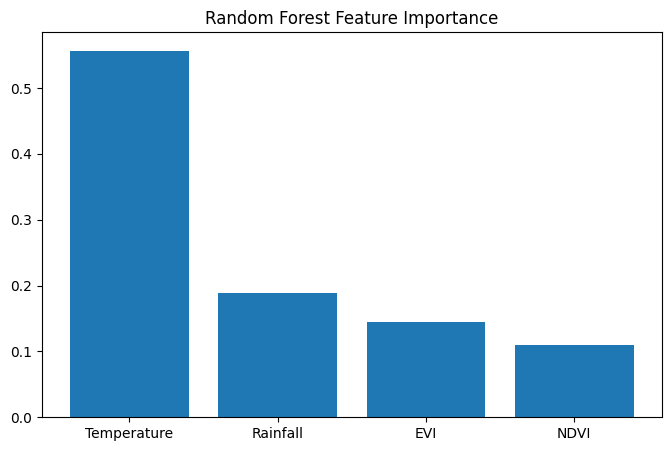

In [127]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.show()

       Feature  Importance
3  Temperature    0.528301
1          EVI    0.197136
2     Rainfall    0.178677
0         NDVI    0.095887


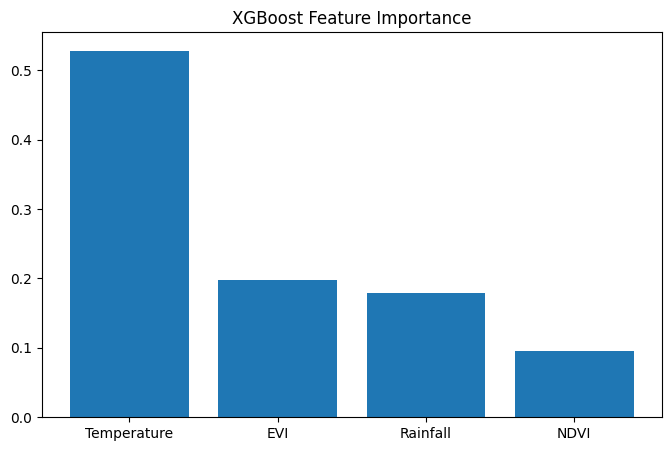

In [128]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.show()

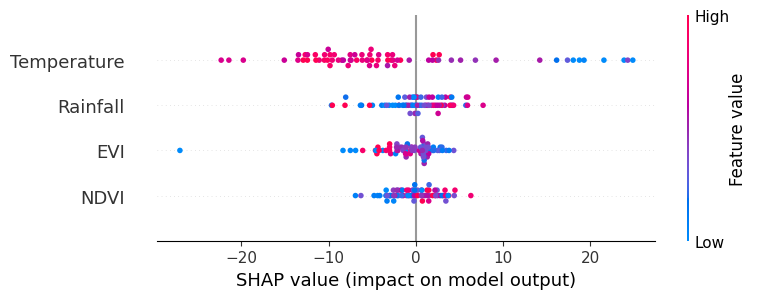

In [129]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

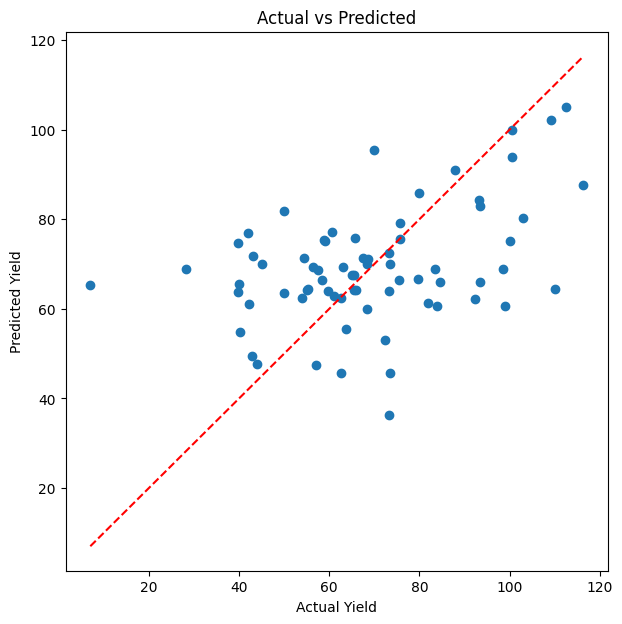

In [130]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    xgb_pred
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted")

plt.show()

In [131]:
import joblib

joblib.dump(
    xgb,
    "Sugarcane_Yield_XGBoost.pkl"
)

joblib.dump(
    rf,
    "Sugarcane_Yield_RF.pkl"
)

['Sugarcane_Yield_RF.pkl']

In [132]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# Create output folder
os.makedirs("Figures", exist_ok=True)

# Load your final dataset
df = merged.copy()      # <-- Replace 'merged' if your final dataframe has another name

# Keep only rows with yield
df = df.dropna(subset=["Yield"])

# -------------------------------
# Yield Distribution
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Yield"], bins=20)
plt.xlabel("Sugarcane Yield (t/ha)")
plt.ylabel("Frequency")
plt.title("Distribution of Sugarcane Yield")
plt.tight_layout()
plt.savefig("Figures/yield_distribution.png", dpi=300)
plt.close()

# -------------------------------
# NDVI
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["NDVI"], bins=20)
plt.xlabel("NDVI")
plt.ylabel("Frequency")
plt.title("Distribution of NDVI")
plt.tight_layout()
plt.savefig("Figures/ndvi_distribution.png", dpi=300)
plt.close()

# -------------------------------
# EVI
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["EVI"], bins=20)
plt.xlabel("EVI")
plt.ylabel("Frequency")
plt.title("Distribution of EVI")
plt.tight_layout()
plt.savefig("Figures/evi_distribution.png", dpi=300)
plt.close()

# -------------------------------
# Rainfall
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Rainfall"], bins=20)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Rainfall")
plt.tight_layout()
plt.savefig("Figures/rainfall_distribution.png", dpi=300)
plt.close()

# -------------------------------
# Temperature
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Temperature"], bins=20)
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature")
plt.tight_layout()
plt.savefig("Figures/temperature_distribution.png", dpi=300)
plt.close()

print("EDA figures saved successfully!")

NameError: name 'merged' is not defined

In [134]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_exit_code', '_i2', 'ee', 'geemap', 'pd', 'gpd', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', '_i11', '_i12', '_i13', '_i14', 'india', 'maharashtra', '_i15', 'Map', '_15', '_i16', 'districts', '_i17', 'first', '_i18', '_i19', 'district_names', '_i20', 'district', 'start', 'end', 'modis', 'ndvi', 'evi', 'rain', 'rainfall', 'temp', 'temperature', '_i21', '_i22', 'name', '_i23', '_i24', '_i25', 'tqdm', '_i26', 'district_list', '_26', '_i27', 'results', 'year', 'month', 'district_name', 'geometry', '_i28', 'satellite_df', '_28', '__js_239', '_i29', 'files', '_i30', '_i31', '_i32', 'yearly_features', '_i33', 'years', 'annual_dataset', '_i34', '_i35', 'YEAR', '_i36', '_i37', 'image', 'table', 'task', '_i38', '_38', '_i39', '_i40', '_i41', '_41', '_i42', '_42', '_i43

In [135]:
print(final_df.columns)
print(final_df.head())

Index(['District', 'Year', 'NDVI', 'EVI', 'Rainfall', 'Temperature', 'Yield'], dtype='object')
     District  Year      NDVI       EVI     Rainfall  Temperature  Yield
0  Ahmadnagar  2010  0.400080  0.237228   966.720314    25.551712  91.40
1    Amravati  2010  0.449930  0.260543  1287.371343    26.916049  69.00
2         Bid  2010  0.407521  0.238991  1007.761665    26.214330  65.90
4       Dhule  2010  0.374176  0.220526   917.438814    26.641337  83.51
5     Jalgaon  2010  0.451454  0.269947   923.853773    27.152040  78.30


In [136]:
import os
import matplotlib.pyplot as plt

os.makedirs("Figures", exist_ok=True)

df = final_df.copy()

df = df.dropna(subset=["Yield"])

In [137]:
print(final_df.columns)

Index(['District', 'Year', 'NDVI', 'EVI', 'Rainfall', 'Temperature', 'Yield'], dtype='object')


In [138]:
import os
import matplotlib.pyplot as plt

# Create folder
os.makedirs("Figures", exist_ok=True)

df = final_df.copy()

# Remove missing yield values
df = df.dropna(subset=["Yield"])

# -------------------------
# Yield
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Yield"], bins=20)
plt.xlabel("Yield (t/ha)")
plt.ylabel("Frequency")
plt.title("Sugarcane Yield Distribution")
plt.tight_layout()
plt.savefig("Figures/yield_distribution.png", dpi=300)
plt.close()

# -------------------------
# NDVI
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(df["NDVI"], bins=20)
plt.xlabel("NDVI")
plt.ylabel("Frequency")
plt.title("NDVI Distribution")
plt.tight_layout()
plt.savefig("Figures/ndvi_distribution.png", dpi=300)
plt.close()

# -------------------------
# EVI
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(df["EVI"], bins=20)
plt.xlabel("EVI")
plt.ylabel("Frequency")
plt.title("EVI Distribution")
plt.tight_layout()
plt.savefig("Figures/evi_distribution.png", dpi=300)
plt.close()

# -------------------------
# Rainfall
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Rainfall"], bins=20)
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.title("Rainfall Distribution")
plt.tight_layout()
plt.savefig("Figures/rainfall_distribution.png", dpi=300)
plt.close()

# -------------------------
# Temperature
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Temperature"], bins=20)
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Temperature Distribution")
plt.tight_layout()
plt.savefig("Figures/temperature_distribution.png", dpi=300)
plt.close()

print("EDA Figures Generated Successfully!")

EDA Figures Generated Successfully!


In [139]:
import matplotlib.pyplot as plt

corr = df[["NDVI","EVI","Rainfall","Temperature","Yield"]].corr()

plt.figure(figsize=(7,6))
plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i,
                 f"{corr.iloc[i,j]:.2f}",
                 ha="center",
                 va="center",
                 fontsize=9)

plt.colorbar()
plt.tight_layout()
plt.savefig("Figures/correlation_heatmap.png", dpi=300)
plt.close()

print("Correlation Heatmap Saved!")

Correlation Heatmap Saved!


In [140]:
import os
print(os.listdir("Figures"))

['temperature_distribution.png', 'rainfall_distribution.png', 'ndvi_distribution.png', 'correlation_heatmap.png', 'evi_distribution.png', 'yield_distribution.png']


In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("Figures", exist_ok=True)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(7,5))
importance.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("Figures/rf_feature_importance.png", dpi=300)
plt.close()

print("RF Feature Importance Saved")

RF Feature Importance Saved


In [142]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(7,5))
importance.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig("Figures/xgb_feature_importance.png", dpi=300)
plt.close()

print("XGBoost Feature Importance Saved")

XGBoost Feature Importance Saved


In [143]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.savefig("Figures/rf_prediction.png", dpi=300)
plt.close()

print("RF Prediction Plot Saved")

RF Prediction Plot Saved


In [144]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, xgb_pred)

min_val = min(y_test.min(), xgb_pred.min())
max_val = max(y_test.max(), xgb_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.savefig("Figures/xgb_prediction.png", dpi=300)
plt.close()

print("XGB Prediction Plot Saved")

XGB Prediction Plot Saved


In [145]:
residual = y_test - rf_pred

plt.figure(figsize=(6,4))

plt.scatter(rf_pred, residual)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("Random Forest Residual Plot")
plt.tight_layout()
plt.savefig("Figures/rf_residual.png", dpi=300)
plt.close()

print("RF Residual Plot Saved")

RF Residual Plot Saved


In [146]:
residual = y_test - xgb_pred

plt.figure(figsize=(6,4))

plt.scatter(xgb_pred, residual)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("XGBoost Residual Plot")
plt.tight_layout()
plt.savefig("Figures/xgb_residual.png", dpi=300)
plt.close()

print("XGB Residual Plot Saved")

XGB Residual Plot Saved


In [147]:
import os

print(sorted(os.listdir("Figures")))

['correlation_heatmap.png', 'evi_distribution.png', 'ndvi_distribution.png', 'rainfall_distribution.png', 'rf_feature_importance.png', 'rf_prediction.png', 'rf_residual.png', 'temperature_distribution.png', 'xgb_feature_importance.png', 'xgb_prediction.png', 'xgb_residual.png', 'yield_distribution.png']


In [148]:
import shutil

shutil.make_archive("Figures", "zip", "Figures")

'/content/Figures.zip'

In [149]:
from google.colab import files
files.download("Figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>